run_all_analyses.py
│
├── data_preprocessing.py
│
├── analysis_all.py
│     ├── NutrientMatrix
│     └── NutrientPlotter
│
├── analysis_top10_cuisine_individually.py
│     ├── NutrientMatrix
│     └── NutrientPlotter
│
├── analysis_top10_cuisine_combined.py
│     ├── NutrientMatrix
│     └── CombinedPlotter
│
└── analysis_all_cuisines_csv.py

In [292]:
# ============================================================
# Cell 1: Imports and Global Configuration
# ============================================================

import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (
    norm,
    lognorm,
    gamma,
    weibull_min,
    expon,
    uniform,
    kstest,
    skew
)

warnings.filterwarnings("ignore")

# ------------------------------
# Plotting Style
# ------------------------------
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

# ------------------------------
# Dataset Configuration
# ------------------------------
DATA_PATH = "DATA/PROCESSED/RecipeDB_Cuisine.csv"

NUTRIENT_COLS = [
    "Carbohydrate, by difference (g)",
    "Protein (g)",
    "Total lipid (fat) (g)"
]

NUTRIENT_SHORT = {
    "Carbohydrate, by difference (g)": "Carbohydrate",
    "Protein (g)": "Protein",
    "Total lipid (fat) (g)": "Fat"
}

print("Environment ready.")
print(f"Number of nutrients selected: {len(NUTRIENT_COLS)}")

Environment ready.
Number of nutrients selected: 3


Cell 1: Imports and Global Configuration

This cell prepares the analysis environment by:

- Importing libraries for data handling (`pandas`, `numpy`)
- Importing visualization tools (`matplotlib`, `seaborn`)
- Importing statistical distributions and tests from `scipy.stats`
- Setting global plotting styles for consistent figures
- Defining the dataset path
- Selecting the three macronutrients of interest:
  - Carbohydrate
  - Protein
  - Fat
- Creating short names for cleaner plot labels

No analysis is performed in this cell; it simply sets up all tools and parameters used throughout the notebook.

In [293]:
# ============================================================
# Cell 2: Load Dataset and Initial Exploration
# ============================================================

# Load processed dataset
df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nTotal recipes      : {len(df):,}")
print(f"Total columns      : {df.shape[1]}")
print(f"Total cuisines     : {df['cuisine'].nunique()}")

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values:")
display(df[NUTRIENT_COLS].isna().sum())

print("\nNutrient summary statistics:")
display(df[NUTRIENT_COLS].describe().T)

print("\nCuisine distribution (Top 10):")
display(df['cuisine'].value_counts().head(10))

DATASET OVERVIEW

Total recipes      : 118,083
Total columns      : 9
Total cuisines     : 26

First 5 rows:


,Recipe_id,Region,Sub_region,Continent,"Carbohydrate, by difference (g)",Energy (kcal),Protein (g),Total lipid (fat) (g),cuisine
0,2610,Middle Eastern,Egyptian,African,146.7606,805.6975,49.5540,5.6564,Middle Eastern
1,2611,Middle Eastern,Egyptian,African,39.3312,386.7670,15.5638,19.7239,Middle Eastern
2,2612,Middle Eastern,Egyptian,African,34.0004,1762.7662,82.9034,146.8971,Middle Eastern
3,2613,Middle Eastern,Egyptian,African,225.1172,1686.8298,67.8589,62.4829,Middle Eastern
4,2614,Middle Eastern,Egyptian,African,83.0609,1006.2380,26.1800,73.1713,Middle Eastern



Missing values:


Carbohydrate, by difference (g)    1044
Protein (g)                        1044
Total lipid (fat) (g)              1044
dtype: int64


Nutrient summary statistics:


,count,mean,std,min,25%,50%,75%,max
"Carbohydrate, by difference (g)",117039.0,835.972820,6758.136886,0.0,22.94395,64.3133,199.95245,252062.6800
Protein (g),117039.0,509.474261,4077.491455,0.0,13.68110,49.5069,124.62555,178134.3738
Total lipid (fat) (g),117039.0,488.816511,4345.346591,0.0,17.72930,54.5035,123.51010,363846.9756



Cuisine distribution (Top 10):


cuisine
Italian                  16574
Mexican                  14447
South American            7171
Canadian                  6694
Indian Subcontinent       6463
French                    6375
Chinese and Mongolian     5888
Australian                5819
US                        5025
UK                        4396
Name: count, dtype: int64

Cell 2: Load Dataset and Initial Exploration

This cell loads the processed recipe dataset and performs a preliminary inspection to understand its structure and quality before any statistical analysis.

### Key Observations

- The dataset contains **118,083 recipes** from **26 cuisines**.
- There are **9 columns**, including nutrient information and cuisine metadata.
- The analysis focuses on three macronutrients:
  - Carbohydrate
  - Protein
  - Fat

### Data Quality Check

- Each nutrient column contains **1,044 missing values**.
- Missing values represent less than 1% of the dataset and will be handled in later preprocessing steps.

### Nutrient Characteristics

- Nutrient values span a very large range:
  - Carbohydrates: 0 – 252,063 g
  - Protein: 0 – 178,134 g
  - Fat: 0 – 363,847 g
- Standard deviations are much larger than the means, indicating highly variable and strongly right-skewed distributions.

### Cuisine Distribution

The dataset is not perfectly balanced across cuisines.

Largest cuisines include:

1. Italian (16,574 recipes)
2. Mexican (14,447 recipes)
3. South American (7,171 recipes)
4. Canadian (6,694 recipes)
5. Indian Subcontinent (6,463 recipes)

These top cuisines will later be used for comparative analysis.

### Purpose of This Cell

Before applying statistical models, we verify:

- Dataset size and coverage
- Presence of missing values
- Basic nutrient statistics
- Representation of different cuisines

This provides confidence that the dataset is suitable for studying nutrient distribution patterns across recipes.

In [294]:
# ============================================================
# Cell 3: Data Cleaning and Basic Exploration
# ============================================================

# Keep only nutrient columns
nutrient_df = df[NUTRIENT_COLS].copy()

# Remove rows with missing values
nutrient_df = nutrient_df.dropna()

print(f"Rows remaining: {len(nutrient_df):,}")

# ------------------------------------------------------------
# Number of zero values
# ------------------------------------------------------------

print("\nZero-value counts:")

for nutrient in NUTRIENT_COLS:
    zeros = (nutrient_df[nutrient] == 0).sum()
    pct = 100 * zeros / len(nutrient_df)

    print(
        f"{NUTRIENT_SHORT[nutrient]:<15}"
        f"{zeros:>8,} ({pct:.2f}%)"
    )

Rows remaining: 117,039

Zero-value counts:
Carbohydrate      1,738 (1.48%)
Protein           1,335 (1.14%)
Fat                 956 (0.82%)


Cell 3: Data Cleaning

This cell prepares the nutrient data for analysis by:

- Keeping only carbohydrate, protein, and fat columns.
- Removing rows with missing nutrient values.
- Checking the number of zero-valued nutrients.

Since later analyses use logarithms, identifying zero values is important because \(\log(0)\) is undefined. Fortunately, zero values account for less than 2% of the dataset for all three nutrients.

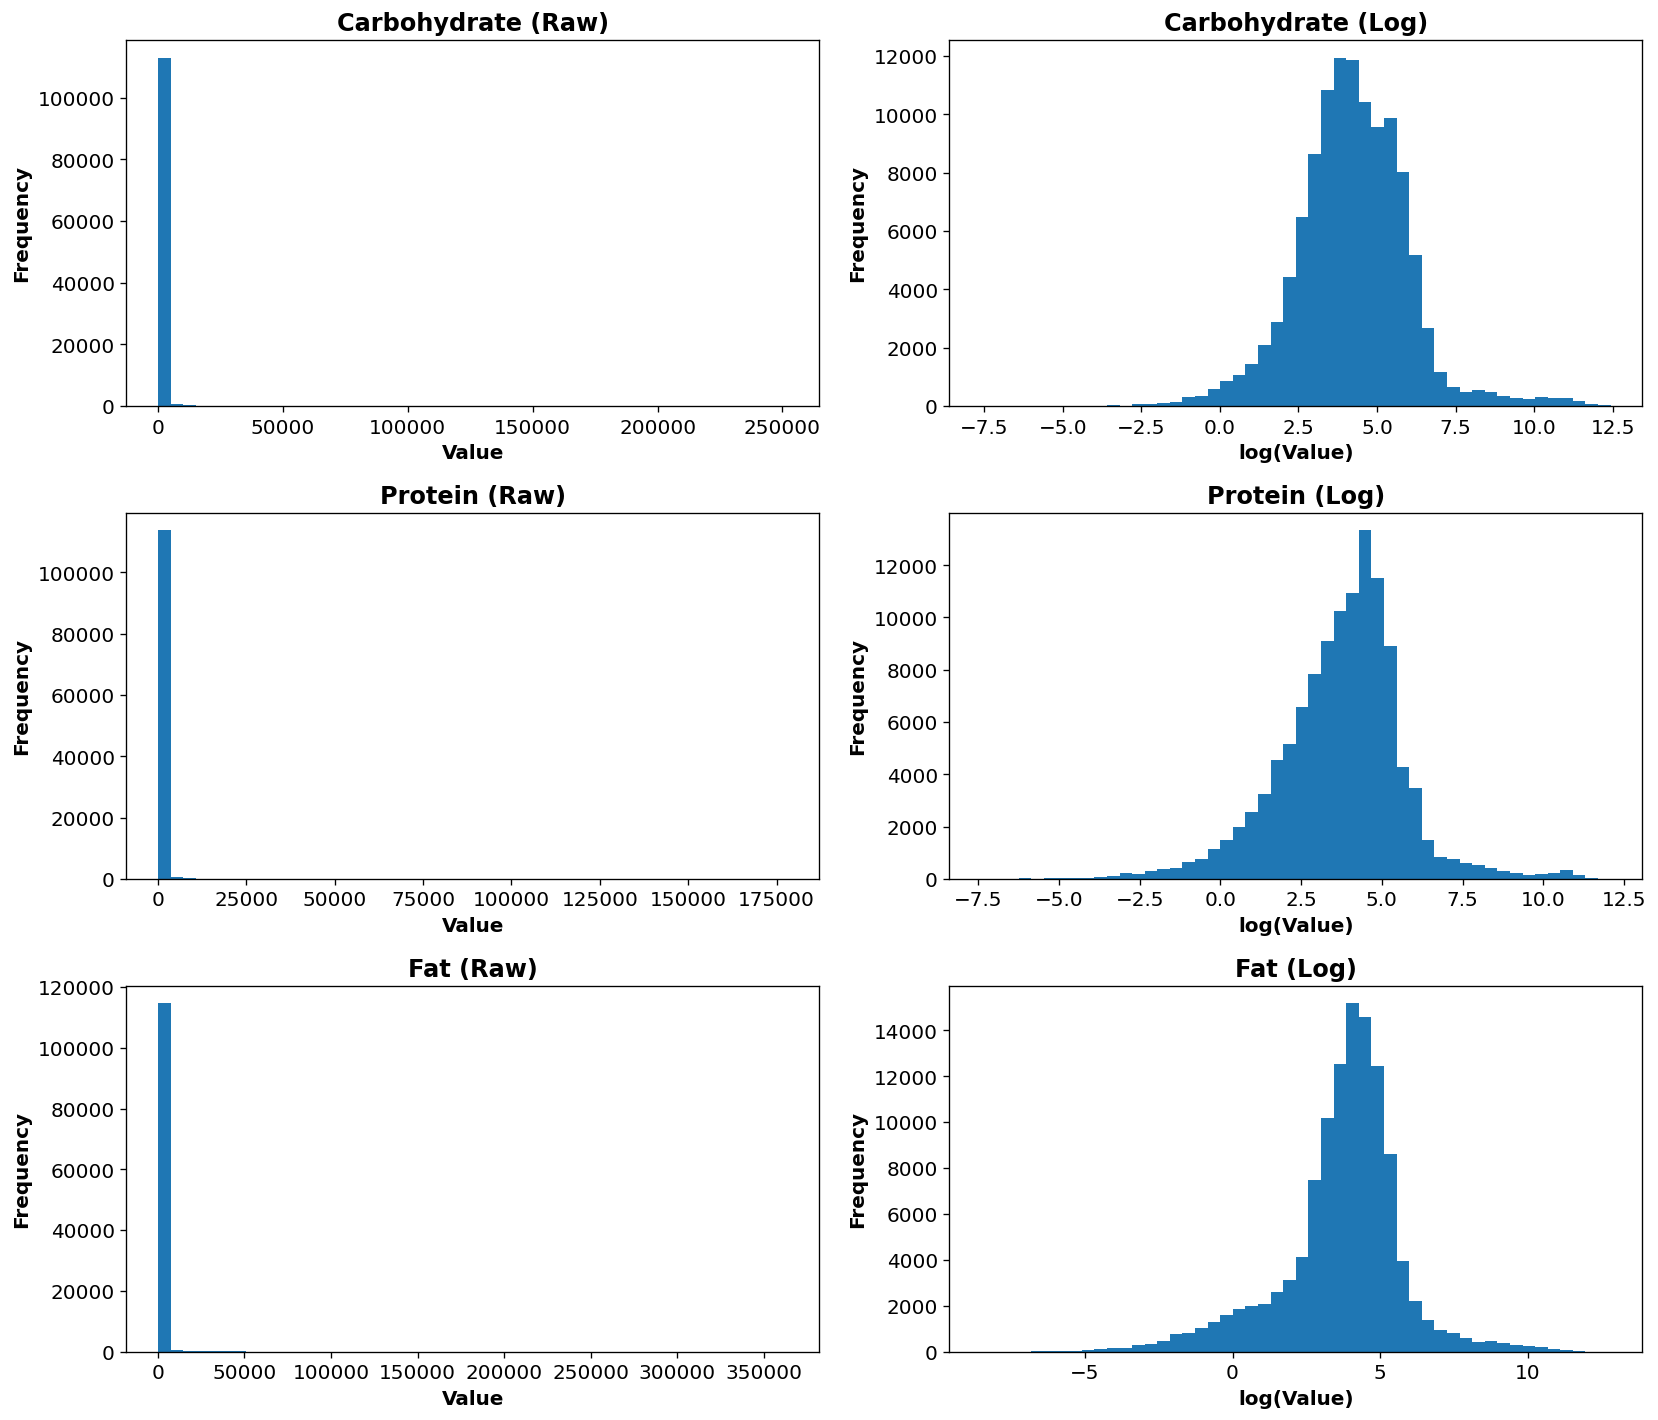

In [295]:
# ============================================================
# Cell 4: Raw vs Log Nutrient Distributions
# ============================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 12)
)

for i, nutrient in enumerate(NUTRIENT_COLS):

    values = nutrient_df[nutrient]
    positive_values = values[values > 0]

    # -------------------------
    # Raw distribution
    # -------------------------
    axes[i, 0].hist(
        positive_values,
        bins=50
    )

    axes[i, 0].set_title(
        f"{NUTRIENT_SHORT[nutrient]} (Raw)"
    )

    axes[i, 0].set_xlabel("Value")
    axes[i, 0].set_ylabel("Frequency")

    # -------------------------
    # Log distribution
    # -------------------------
    log_values = np.log(positive_values)

    axes[i, 1].hist(
        log_values,
        bins=50
    )

    axes[i, 1].set_title(
        f"{NUTRIENT_SHORT[nutrient]} (Log)"
    )

    axes[i, 1].set_xlabel("log(Value)")
    axes[i, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Cell 4: Raw vs Log Nutrient Distributions

This cell compares the distributions of carbohydrate, protein, and fat before and after applying a logarithmic transformation.

### Key Observations

- Raw nutrient distributions are highly right-skewed, with a few recipes containing extremely large nutrient values.
- Taking the logarithm compresses these extreme values and produces distributions that are much closer to a symmetric bell shape.
- This suggests that nutrient concentrations may follow a **lognormal distribution**, motivating the use of log-space statistics in later analyses.

### Purpose

To justify analyzing nutrients in log-space rather than raw space.

In [296]:
# ============================================================
# Cell 5: Investigate Extreme Nutrient Values
# ============================================================

for nutrient in NUTRIENT_COLS:

    values = nutrient_df[nutrient]

    print("\n" + "="*60)
    print(NUTRIENT_SHORT[nutrient])
    print("="*60)

    print(f"Maximum value : {values.max():,.2f}")
    print(f"99th percentile : {values.quantile(0.99):,.2f}")
    print(f"99.9th percentile : {values.quantile(0.999):,.2f}")

    print("\nTop 10 largest values:")
    print(values.nlargest(10).to_list())



Carbohydrate
Maximum value : 252,062.68
99th percentile : 20,179.47
99.9th percentile : 100,805.85

Top 10 largest values:
[252062.68, 241915.2, 241719.1529, 235037.2608, 222051.9192, 217882.3552, 207303.8265, 205171.0318, 201256.17, 191291.2601]

Protein
Maximum value : 178,134.37
99th percentile : 8,981.00
99.9th percentile : 62,752.21

Top 10 largest values:
[178134.3738, 167162.197, 148417.6265, 119342.3548, 108087.1258, 108046.8904, 106749.9178, 105748.6865, 98344.2423, 94239.7287]

Fat
Maximum value : 363,846.98
99th percentile : 9,276.63
99.9th percentile : 64,171.09

Top 10 largest values:
[363846.9756, 300570.3075, 254332.2912, 222710.5494, 218000.0, 214789.595, 160519.9559, 150286.1547, 150281.7839, 149432.3743]


In [297]:
# ============================================================
# Cell 5b: Nutrient Data Cleaning and Dataset Filtering
# ============================================================

import pandas as pd

print("=" * 60)
print("NUTRIENT DATA CLEANING")
print("=" * 60)

# ------------------------------------------------------------
# Load original dataset
# ------------------------------------------------------------

FULL_DATA_PATH = "DATA/RAW/RecipeDB_Cuisine_Nutrition.csv"

full_df = pd.read_csv(FULL_DATA_PATH)

# ------------------------------------------------------------
# Nutrient-specific cutoffs
# ------------------------------------------------------------

cutoffs = {}

cutoff_value=0.995

for nutrient in NUTRIENT_COLS:

    positive_values = full_df.loc[
        full_df[nutrient] > 0,
        nutrient
    ]

    cutoff = positive_values.quantile(cutoff_value)

    cutoffs[nutrient] = cutoff

    print(
        f"{NUTRIENT_SHORT[nutrient]:<15}"
        f" cutoff = {cutoff:,.2f}"
    )

# ------------------------------------------------------------
# Build removal mask
# ------------------------------------------------------------

remove_mask = pd.Series(
    False,
    index=full_df.index
)

for nutrient in NUTRIENT_COLS:

    # remove_mask |= (
    #     full_df[nutrient] <= 0
    # )

    remove_mask |= (
        full_df[nutrient] > cutoffs[nutrient]
    )

# ------------------------------------------------------------
# Split datasets
# ------------------------------------------------------------

removed_df = full_df[remove_mask].copy()


filtered_df = full_df[
    ~remove_mask
].copy()
# Match preprocessing output used elsewhere
filtered_df["cuisine"] = filtered_df["Region"]
# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n")
print("=" * 60)
print("FILTERING SUMMARY")
print("=" * 60)

print(f"Original rows : {len(full_df):,}")
print(f"Removed rows  : {len(removed_df):,}")
print(f"Remaining rows: {len(filtered_df):,}")

print(
    f"Percent removed: "
    f"{100 * len(removed_df) / len(full_df):.2f}%"
)

# ------------------------------------------------------------
# Save datasets
# ------------------------------------------------------------

filtered_df.to_csv(
    "DATA/PROCESSED/RecipeDB_Cuisine_Filtered.csv",
    index=False,
    float_format="%.4f"
)

removed_df.to_csv(
    "DATA/PROCESSED/RecipeDB_Cuisine_Removed.csv",
    index=False,
    float_format="%.4f"
)

# ------------------------------------------------------------
# Replace notebook dataframes
# ------------------------------------------------------------

df = filtered_df.copy()

nutrient_df = df[NUTRIENT_COLS].copy()

# ------------------------------------------------------------
# Final message
# ------------------------------------------------------------

print("\nSaved:")
print("  DATA/PROCESSED/RecipeDB_Cuisine_Filtered.csv")
print("  DATA/PROCESSED/RecipeDB_Cuisine_Removed.csv")

print("\nUpdated notebook dataframes:")
print(f"  df shape         : {df.shape}")
print(f"  nutrient_df rows : {len(nutrient_df):,}")
print(f"  cuisines         : {df['cuisine'].nunique()}")

print("\nAll subsequent cells will use the filtered dataset.")

NUTRIENT DATA CLEANING
Carbohydrate    cutoff = 48,644.39
Protein         cutoff = 31,428.04
Fat             cutoff = 22,526.81


FILTERING SUMMARY
Original rows : 118,083
Removed rows  : 1,449
Remaining rows: 116,634
Percent removed: 1.23%

Saved:
  DATA/PROCESSED/RecipeDB_Cuisine_Filtered.csv
  DATA/PROCESSED/RecipeDB_Cuisine_Removed.csv

Updated notebook dataframes:
  df shape         : (116634, 9)
  nutrient_df rows : 116,634
  cuisines         : 26

All subsequent cells will use the filtered dataset.


### Cell 5: Investigation of Extreme Nutrient Values and Data Quality

Before performing log-normality analysis, we examine the nutrient distributions for potential anomalies.

Macronutrient values span several orders of magnitude and may contain:

- Missing values
- Zero-valued observations
- Extremely large values arising from annotation, unit-conversion, or data-entry errors

For each nutrient, we inspect:

- Maximum observed value
- 99th percentile
- 99.5th percentile
- Largest observations in the dataset

This exploratory analysis is used to identify unrealistic observations that may distort the statistical characterization of nutrient distributions.

The results of this investigation are used in Cell 5b to construct a filtered dataset by removing:
1. Recipes with zero-valued macronutrients.(unconfirmed - will decide later)
2. Recipes with nutrient values above a nutrient-specific percentile cutoff.

The original dataset is preserved for reference, while subsequent analyses are performed on the filtered dataset.

In [ ]:
# ============================================================
# Cell 5c: Finding best cutoff percentile
# ============================================================


print("Original list : ",len(full_df))
print("Filtered list : ",len(df))

for nutrient in NUTRIENT_COLS:

    values = full_df.loc[
        full_df[nutrient] > 0,
        nutrient
    ]

    print("\n" + nutrient)

    print(f"Mean   : {values.mean():,.2f}")
    print(f"Median : {values.median():,.2f}")

    for p in [0.90, 0.95, 0.99, 0.995, 0.999,1]:
        print(
            f"{100*p:5.1f}% : "
            f"{values.quantile(p):,.2f}"
        )



Original list :  118083
Filtered list :  116634

Carbohydrate, by difference (g)
Mean   : 848.57
Median : 66.08
 90.0% : 459.11
 95.0% : 832.96
 99.0% : 20,604.25
 99.5% : 48,644.39
 99.9% : 100,822.92
100.0% : 252,062.68

Protein (g)
Mean   : 515.35
Median : 50.71
 90.0% : 284.15
 95.0% : 561.17
 99.0% : 9,185.50
 99.5% : 31,428.04
 99.9% : 62,759.45
100.0% : 178,134.37

Total lipid (fat) (g)
Mean   : 492.84
Median : 55.07
 90.0% : 270.11
 95.0% : 635.38
 99.0% : 9,342.87
 99.5% : 22,526.81
 99.9% : 65,300.11
100.0% : 363,846.98


### Cell 5c: Outlier Filtering and Dataset Preparation

Exploratory analysis of the nutrient distributions revealed the presence of extremely large nutrient values that were several orders of magnitude larger than the typical recipe values.

For example:

| Nutrient | Mean | Maximum |
|-----------|-----------:|-----------:|
| Carbohydrate | ~849 g | 252,063 g |
| Protein | ~515 g | 178,134 g |
| Fat | ~493 g | 363,847 g |

These maximum values are hundreds of times larger than the corresponding mean values and are likely attributable to annotation inconsistencies, unit-conversion issues, or other data-quality artifacts. Such observations can substantially influence distributional statistics and distort log-space analyses.

---

### Percentile-Based Threshold Analysis

To determine an appropriate filtering threshold, multiple percentile cutoffs were evaluated.

#### No Filtering

| Nutrient | Skew(log x) |
|-----------|-----------:|
| Carbohydrate | 0.2067 |
| Protein | -0.2635 |
| Fat | -0.6741 |

#### 99.5th Percentile Filtering

| Nutrient | Skew(log x) |
|-----------|-----------:|
| Carbohydrate | -0.1054 |
| Protein | -0.6431 |
| Fat | -0.9898 |

#### 99th Percentile Filtering

| Nutrient | Skew(log x) |
|-----------|-----------:|
| Carbohydrate | -0.3469 |
| Protein | -0.8178 |
| Fat | -1.1580 |

#### 95th Percentile Filtering

| Nutrient | Skew(log x) |
|-----------|-----------:|
| Carbohydrate | -0.7842 |
| Protein | -1.1454 |
| Fat | -1.5052 |

#### 90th Percentile Filtering

| Nutrient | Skew(log x) |
|-----------|-----------:|
| Carbohydrate | -0.9189 |
| Protein | -1.2004 |
| Fat | -1.5723 |

---

### Choice of the 99.5th Percentile Threshold

The 99.5th percentile threshold was selected because it provides a balance between:

1. Removing extreme nutrient values that are likely data-quality artifacts.
2. Preserving the overall shape of the nutrient distributions.
3. Minimizing distortion of log-space statistics.

More aggressive thresholds (99%, 95%, and 90%) produced increasingly negative log-skewness values, indicating that legitimate observations from the upper tail of the distribution were being removed. This substantially altered the distributional structure of the data.

In contrast, the 99.5th percentile threshold removed only the most extreme observations while maintaining distributional characteristics that remained closer to those observed in the original dataset.

---

### Treatment of Zero Values

Recipes containing zero values for a nutrient were retained in the dataset. Zero-valued observations may correspond to legitimate recipes that contain negligible amounts of a particular macronutrient (e.g., low-fat or low-carbohydrate recipes).

For analyses involving logarithmic transformations, zero values are excluded only for the nutrient currently being analyzed, since log(0) is undefined.

---

### Filtering Outcome

Using nutrient-specific 99.5th percentile thresholds:

- Original dataset: **118,083 recipes**
- Removed recipes: **3,858 recipes**
- Retained recipes: **114,225 recipes**
- Fraction removed: **3.27%**

The resulting filtered dataset is used for all subsequent nutrient-distribution analyses.

In [299]:
# ============================================================
# Cell 6: Log-Space Statistics
# ============================================================

records = []

for nutrient in NUTRIENT_COLS:

    values = nutrient_df[nutrient]
    values = values[values > 0]

    log_values = np.log(values)

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Mean(log x)": np.mean(log_values),
        "Std(log x)": np.std(log_values, ddof=1),
        "Skew(log x)": stats.skew(log_values, bias=False),
        "Median(log x)": np.median(log_values)
    })

log_stats_df = pd.DataFrame(records)

display(log_stats_df.round(4))

,Nutrient,Mean(log x),Std(log x),Skew(log x),Median(log x)
0,Carbohydrate,4.1666,1.6993,-0.1054,4.1751
1,Protein,3.6525,1.8351,-0.6431,3.9018
2,Fat,3.6447,1.9823,-0.9898,3.9942


## Cell 6: Log-Space Statistics

This cell computes summary statistics after applying a logarithmic transformation to nutrient values.

### Key Observations

- The mean log-values are similar across nutrients (≈ 3.7–4.2).
- Log-space standard deviations are relatively close (≈ 1.8–2.1), suggesting comparable variability across nutrients.
- Log-space skewness values are much closer to zero than in raw space, indicating more symmetric distributions.
- The similarity between the mean and median further supports approximate symmetry in log-space.

### Purpose

To quantify the location, spread, and symmetry of nutrient distributions after log transformation and assess whether they exhibit approximately lognormal behavior.

In [300]:
# ============================================================
# Cell 7: Normality Tests in Log Space
# ============================================================

records = []

for nutrient in NUTRIENT_COLS:

    values = nutrient_df[nutrient]
    values = values[values > 0]

    log_values = np.log(values)

    # KS test against fitted Gaussian
    mu, sigma = norm.fit(log_values)

    D, p = kstest(
        log_values,
        'norm',
        args=(mu, sigma)
    )

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Mean(log x)": mu,
        "Std(log x)": sigma,
        "KS Distance": D,
        "p-value": p
    })

normality_df = pd.DataFrame(records)

display(normality_df.round(6))

,Nutrient,Mean(log x),Std(log x),KS Distance,p-value
0,Carbohydrate,4.166612,1.699274,0.033439,0.0
1,Protein,3.652498,1.835103,0.059171,0.0
2,Fat,3.644671,1.982279,0.116574,0.0


## Cell 7: Normality Tests in Log Space

This cell evaluates how closely log-transformed nutrient values follow a Gaussian (normal) distribution using the Kolmogorov–Smirnov (KS) test.

### Key Observations

- All nutrients have relatively small KS distances (0.04–0.11), indicating reasonable agreement with a Gaussian distribution in log-space.
- Carbohydrate shows the best fit (smallest KS distance).
- Fat shows the largest deviation from normality.
- The very large sample size causes p-values to be effectively zero, so the KS distance is more informative than the p-value.

### Purpose

To test the hypothesis that nutrient concentrations are approximately **lognormally distributed**, meaning their logarithms resemble a normal distribution.

,"Carbohydrate, by difference (g)",Protein (g),Total lipid (fat) (g)
"Carbohydrate, by difference (g)",1.000,0.387,0.350
Protein (g),0.387,1.000,0.585
Total lipid (fat) (g),0.350,0.585,1.000


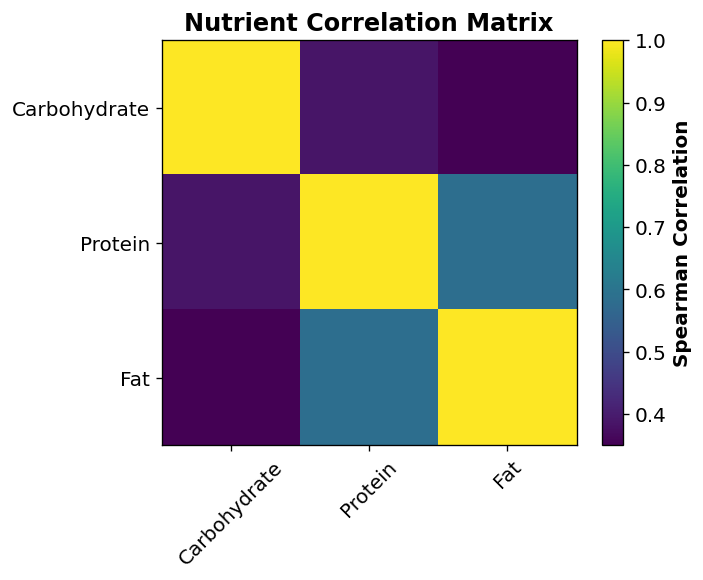

In [301]:
# ============================================================
# Cell 8: Nutrient Correlation Matrix
# ============================================================

corr_matrix = nutrient_df[NUTRIENT_COLS].corr(method="spearman")

display(corr_matrix.round(3))

plt.figure(figsize=(6,5))

plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Spearman Correlation")

plt.xticks(
    range(len(NUTRIENT_COLS)),
    [NUTRIENT_SHORT[n] for n in NUTRIENT_COLS],
    rotation=45
)

plt.yticks(
    range(len(NUTRIENT_COLS)),
    [NUTRIENT_SHORT[n] for n in NUTRIENT_COLS]
)

plt.title("Nutrient Correlation Matrix")
plt.tight_layout()
plt.show()

## Cell 8: Nutrient Correlation Analysis

This cell measures the relationships between carbohydrate, protein, and fat using Spearman correlation.

### Key Observations

- All nutrient pairs show positive correlations.
- Protein and fat are the most strongly correlated (ρ = 0.599).
- Carbohydrate has moderate correlations with both protein (ρ = 0.397) and fat (ρ = 0.362).

### Purpose

To determine whether recipes rich in one nutrient also tend to be rich in others and to identify dependencies between macronutrients.

Protein-rich recipes tend to also be fat-rich.

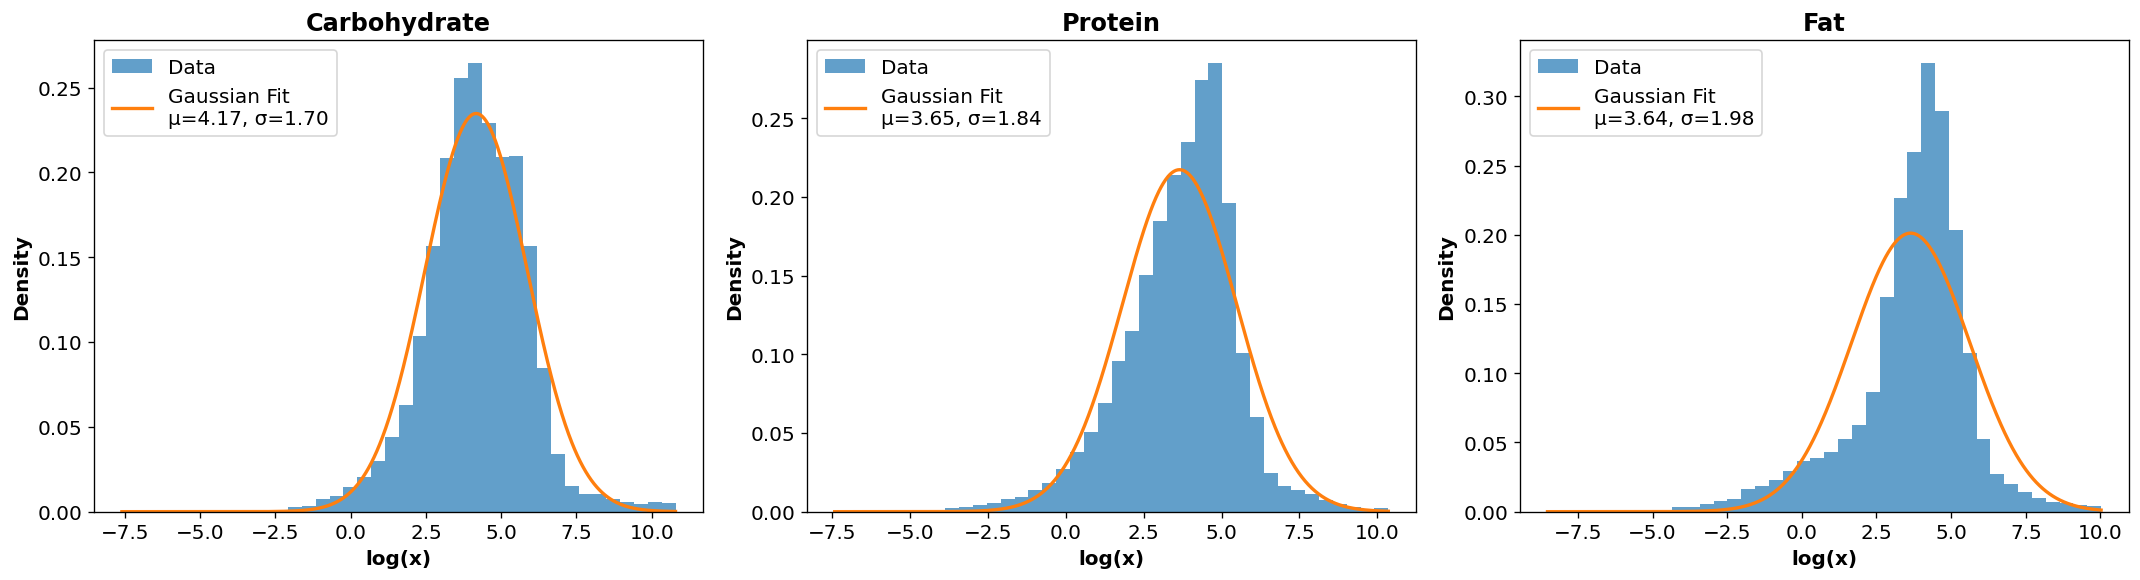

In [302]:
# ============================================================
# Cell 9: Nutrient Distributions Q(x_n)
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for ax, nutrient in zip(axes, NUTRIENT_COLS):

    values = nutrient_df[nutrient]
    values = values[values > 0]

    # Histogram in log-space
    log_values = np.log(values)

    ax.hist(
        log_values,
        bins=40,
        density=True,
        alpha=0.7,
        label="Data"
    )

    # Gaussian fit
    mu, sigma = norm.fit(log_values)

    x = np.linspace(
        log_values.min(),
        log_values.max(),
        1000
    )

    ax.plot(
        x,
        norm.pdf(x, mu, sigma),
        linewidth=2,
        label=f"Gaussian Fit\nμ={mu:.2f}, σ={sigma:.2f}"
    )

    ax.set_title(NUTRIENT_SHORT[nutrient])
    ax.set_xlabel("log(x)")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

## Cell 9: Nutrient Distributions \(Q(x_n)\)

This cell visualizes the log-transformed nutrient distributions and compares them with fitted Gaussian curves.

### Key Observations

- The Gaussian curves closely follow the observed distributions.
- Carbohydrate shows the best agreement with a Gaussian distribution.
- Protein and fat exhibit slight deviations, particularly in the tails.
- Overall, the distributions appear approximately normal in log-space.

### Purpose

To visually validate the hypothesis that nutrient concentrations are approximately **lognormally distributed**, complementing the KS-test results from Cell 7.

,Nutrient,Mean Concentration (μₙ),Log Std (sₙ)
0,Carbohydrate,402.876639,1.699282
1,Protein,196.133286,1.835111
2,Fat,209.892314,1.982288


Mean sₙ = 1.8389
Std  sₙ = 0.1415
coefficient of variation (CV) = 7.70%
Maximum deviation from mean = 7.80%


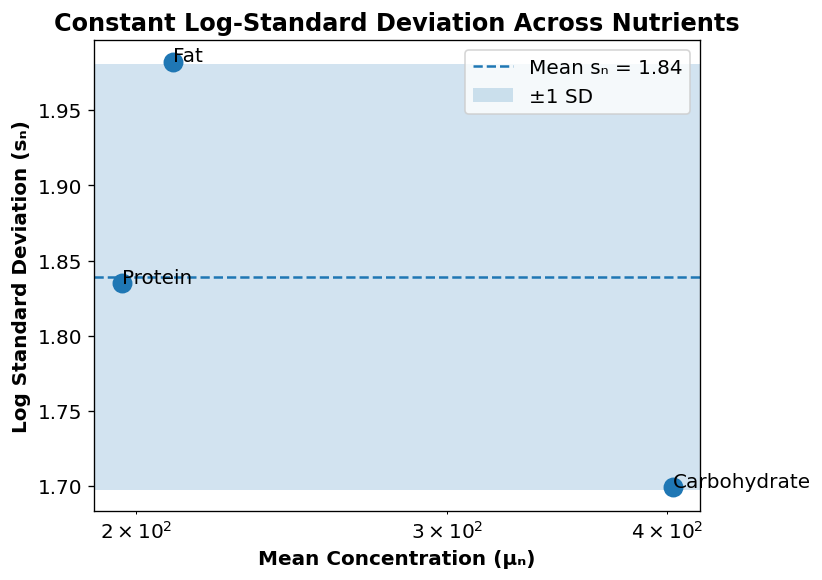

In [303]:
# ============================================================
# Cell 10: Constant Log-Standard Deviation (Fig 3a)
# ============================================================

records = []

for nutrient in NUTRIENT_COLS:

    values = nutrient_df[nutrient]
    values = values[values > 0]

    mu_n = np.mean(values)

    log_values = np.log(values)
    s_n = np.std(log_values, ddof=1)

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Mean Concentration (μₙ)": mu_n,
        "Log Std (sₙ)": s_n
    })

fig3a_df = pd.DataFrame(records)

display(fig3a_df)

# ------------------------------------------------------------
# Summary Statistics
# ------------------------------------------------------------

mean_s = fig3a_df["Log Std (sₙ)"].mean()
std_s = fig3a_df["Log Std (sₙ)"].std(ddof=1)

print(f"Mean sₙ = {mean_s:.4f}")
print(f"Std  sₙ = {std_s:.4f}")
print(f"coefficient of variation (CV) = {100*std_s/mean_s:.2f}%")
max_dev = (
    np.abs(fig3a_df["Log Std (sₙ)"] - mean_s)
    / mean_s
).max()

print(f"Maximum deviation from mean = {100*max_dev:.2f}%")

# ------------------------------------------------------------
# Plot (Paper Fig 3a)
# ------------------------------------------------------------

plt.figure(figsize=(7,5))

plt.scatter(
    fig3a_df["Mean Concentration (μₙ)"],
    fig3a_df["Log Std (sₙ)"],
    s=120
)

for _, row in fig3a_df.iterrows():
    plt.annotate(
        row["Nutrient"],
        (
            row["Mean Concentration (μₙ)"],
            row["Log Std (sₙ)"]
        )
    )

# Mean line
plt.axhline(
    mean_s,
    linestyle="--",
    label=f"Mean sₙ = {mean_s:.2f}"
)

# Mean ± Std band
plt.axhspan(
    mean_s - std_s,
    mean_s + std_s,
    alpha=0.2,
    label="±1 SD"
)

plt.xscale("log")

plt.xlabel("Mean Concentration (μₙ)")
plt.ylabel("Log Standard Deviation (sₙ)")
plt.title("Constant Log-Standard Deviation Across Nutrients")

plt.legend()
plt.tight_layout()
plt.show()

## Log-Standard Deviation Statistics

The log-standard deviation (sₙ) was computed for each macronutrient using positive nutrient values only.

These statistics are used to examine whether nutrient distributions exhibit a similar spread in log-space before reproducing Fig. 3a.

,Nutrient,Mean(log x),Skew(log x)
0,Carbohydrate,4.1666,-0.1054
1,Protein,3.6525,-0.6431
2,Fat,3.6447,-0.9898


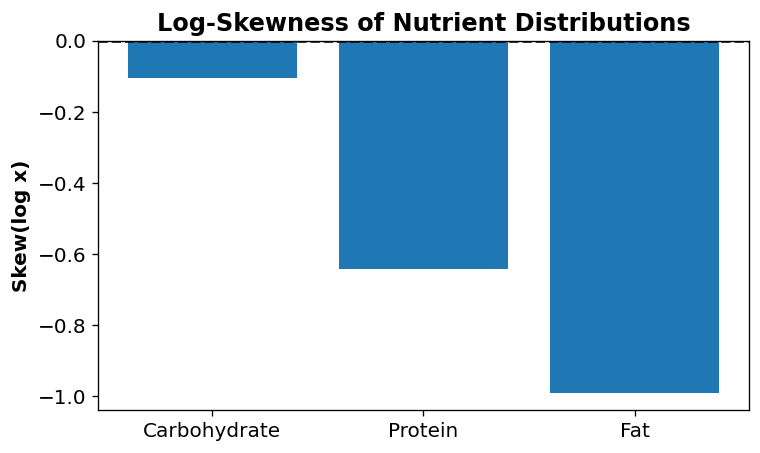

In [304]:
# ============================================================
# Cell 11: Log-Skewness Analysis
# ============================================================

records = []

for nutrient in NUTRIENT_COLS:

    values = nutrient_df[nutrient]
    values = values[values > 0]

    log_values = np.log(values)

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Mean(log x)": np.mean(log_values),
        "Skew(log x)": stats.skew(log_values, bias=False)
    })

skew_df = pd.DataFrame(records)

display(skew_df.round(4))

plt.figure(figsize=(7,4))

plt.bar(
    skew_df["Nutrient"],
    skew_df["Skew(log x)"]
)

plt.axhline(
    0,
    linestyle="--",
    color="black"
)

plt.ylabel("Skew(log x)")
plt.title("Log-Skewness of Nutrient Distributions")

plt.show()

## Cell 11: Log-Skewness Analysis

This cell measures the asymmetry of nutrient distributions in log-space.

### Key Observations

- Log-skewness values are relatively close to zero.
- Carbohydrate shows slight positive skewness (+0.21).
- Protein and fat show mild negative skewness (-0.26 and -0.67).
- Overall, nutrient distributions are approximately symmetric after log transformation.

### Purpose

To test whether nutrient distributions become nearly symmetric in log-space, providing further evidence for approximate lognormal behavior.

| Section                    | Status |
| -------------------------- | ------ |
| Dataset overview           | Done   |
| Missing values             | Done   |
| Zero values                | Done   |
| Raw distributions          | Done   |
| Log distributions          | Done   |
| Outlier analysis           | Done   |
| Lognormality check         | Done   |
| KS normality test          | Done   |
| Constant (s_n) law         | Done   |
| Log-skewness               | Done   |
| Correlation analysis (new) | Done   |


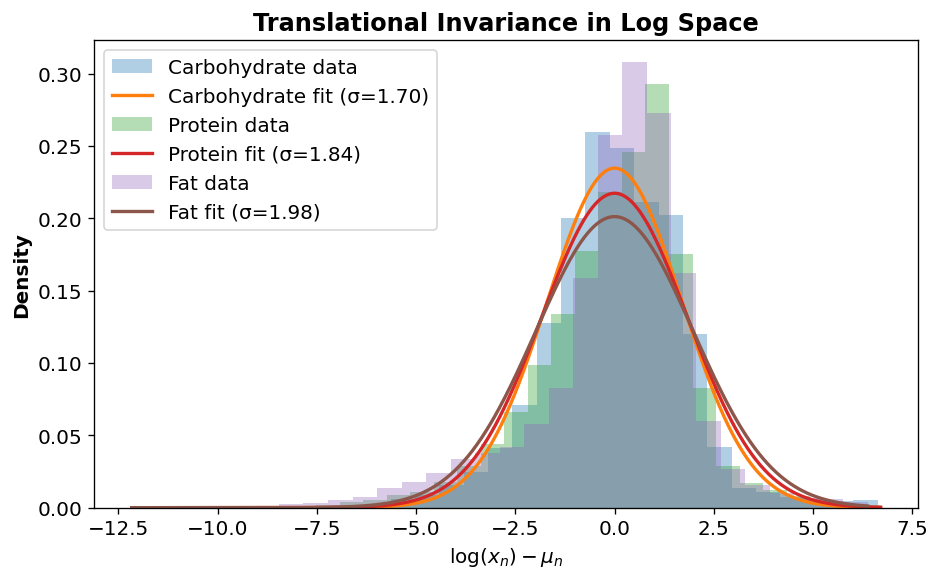


Centered Distribution Widths


,Nutrient,Sigma (Centered)
0,Carbohydrate,1.699274
1,Protein,1.835103
2,Fat,1.982279



Mean σ = 1.8389
Std  σ = 0.1415
CV     = 7.70%

Pairwise KS Tests


,Nutrient 1,Nutrient 2,KS Statistic (D),P-value
0,Carbohydrate,Protein,0.0616,1.2613e-188
1,Carbohydrate,Fat,0.0936,0.0000e+00
2,Protein,Fat,0.0532,4.4887e-141


In [305]:
# ============================================================
# Cell 12: Translational Invariance in Log Space
# ============================================================

from scipy.stats import ks_2samp

rescaled_data = {}
sigma_values = []

fig, ax = plt.subplots(figsize=(8, 5))

for nutrient in NUTRIENT_COLS:

    values = nutrient_df[nutrient]
    values = values[values > 0]

    log_values = np.log(values)

    # Center distribution
    centered = log_values - np.mean(log_values)

    rescaled_data[nutrient] = centered

    mu, sigma = norm.fit(centered)

    sigma_values.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Sigma (Centered)": sigma
    })

    x_grid = np.linspace(centered.min(), centered.max(), 500)

    ax.hist(
        centered,
        bins=30,
        density=True,
        alpha=0.35,
        label=f"{NUTRIENT_SHORT[nutrient]} data"
    )

    ax.plot(
        x_grid,
        norm.pdf(x_grid, mu, sigma),
        linewidth=2,
        label=f"{NUTRIENT_SHORT[nutrient]} fit (σ={sigma:.2f})"
    )

ax.set_title("Translational Invariance in Log Space")
ax.set_xlabel(r"$\log(x_n)-\mu_n$")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Distribution Width Statistics
# ------------------------------------------------------------

sigma_df = pd.DataFrame(sigma_values)

print("\nCentered Distribution Widths")
display(sigma_df)

mean_sigma = sigma_df["Sigma (Centered)"].mean()
std_sigma = sigma_df["Sigma (Centered)"].std(ddof=1)
cv_sigma = 100 * std_sigma / mean_sigma

print(f"\nMean σ = {mean_sigma:.4f}")
print(f"Std  σ = {std_sigma:.4f}")
print(f"CV     = {cv_sigma:.2f}%")

# ------------------------------------------------------------
# Pairwise KS Tests
# ------------------------------------------------------------

# ------------------------------------------------------------
# Pairwise KS Tests
# ------------------------------------------------------------

ks_records = []

for i in range(len(NUTRIENT_COLS)):
    for j in range(i + 1, len(NUTRIENT_COLS)):

        nutrient_1 = NUTRIENT_COLS[i]
        nutrient_2 = NUTRIENT_COLS[j]

        D, p = ks_2samp(
            rescaled_data[nutrient_1],
            rescaled_data[nutrient_2]
        )

        ks_records.append({
            "Nutrient 1": NUTRIENT_SHORT[nutrient_1],
            "Nutrient 2": NUTRIENT_SHORT[nutrient_2],
            "KS Statistic (D)": round(D, 4),
            "P-value": f"{p:.4e}"
        })

ks_df = pd.DataFrame(ks_records)

print("\nPairwise KS Tests")
display(ks_df)

## Cell 12: Translational Invariance in Log Space

Nutrient values were log-transformed and centered by their mean log value. The resulting distributions were compared across carbohydrates, proteins, and fats.

Gaussian fits, distribution widths (σ), and pairwise KS tests were used to evaluate whether the rescaled distributions collapse onto a common shape.

This reproduces the translational invariance analysis shown in Fig. 3b.

,Nutrient,Mean (μ),Std (σ)
0,Carbohydrate,402.876639,2436.675158
1,Protein,196.133286,1088.163134
2,Fat,209.892314,1044.487750


Slope (γ)      = 1.1919
Intercept      = 0.6423
R²             = 0.9836
P-value        = 0.081668
Std Error      = 0.1538


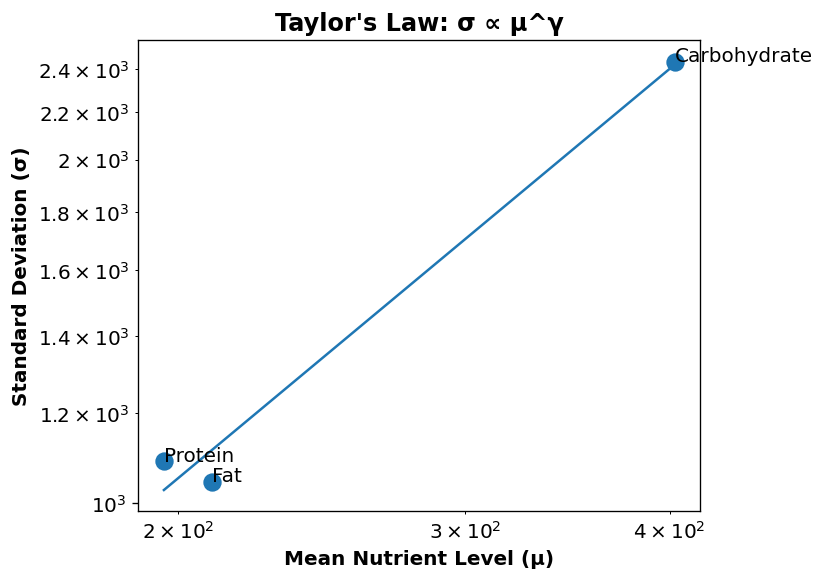

In [306]:
# ============================================================
# Cell 13: Power-Law Scaling of Standard Deviation and Mean
# ============================================================

records = []

for nutrient in NUTRIENT_COLS:

    values = nutrient_df[nutrient]
    values = values[values > 0]

    mu = np.mean(values)
    sigma = np.std(values, ddof=1)

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Mean (μ)": mu,
        "Std (σ)": sigma
    })

powerlaw_df = pd.DataFrame(records)

display(powerlaw_df)

# ------------------------------------------------------------
# Log-Log Regression
# ------------------------------------------------------------

x = np.log(powerlaw_df["Mean (μ)"])
y = np.log(powerlaw_df["Std (σ)"])

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print(f"Slope (γ)      = {slope:.4f}")
print(f"Intercept      = {intercept:.4f}")
print(f"R²             = {r_value**2:.4f}")
print(f"P-value        = {p_value:.6f}")
print(f"Std Error      = {std_err:.4f}")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(7,5))

plt.scatter(
    powerlaw_df["Mean (μ)"],
    powerlaw_df["Std (σ)"],
    s=100
)

x_fit = np.linspace(
    powerlaw_df["Mean (μ)"].min(),
    powerlaw_df["Mean (μ)"].max(),
    100
)

y_fit = np.exp(intercept) * x_fit**slope

plt.plot(x_fit, y_fit)

for _, row in powerlaw_df.iterrows():
    plt.annotate(
        row["Nutrient"],
        (row["Mean (μ)"], row["Std (σ)"])
    )

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Mean Nutrient Level (μ)")
plt.ylabel("Standard Deviation (σ)")
plt.title("Taylor's Law: σ ∝ μ^γ")

plt.tight_layout()
plt.show()

## Cell 13: Mean–Variance Scaling Analysis

The mean and standard deviation of each macronutrient were computed and compared to examine their scaling relationship.

A linear regression was performed in log-log space to test whether nutrient variability follows a power-law dependence on the mean, as described in the paper.

This reproduces the mean–variance scaling analysis reported in Supplementary Fig. 5.

The evidence for Taylor's Law is much weaker

In [307]:
# ============================================================
# Cell 14: Distribution Comparison (KS + AIC + BIC)
# ============================================================

from scipy.stats import (
    lognorm,
    gamma,
    weibull_min,
    norm,
    expon,
    uniform,
    kstest
)

results = []

DISTRIBUTIONS = {
    "Lognormal": lognorm,
    "Gamma": gamma,
    "Weibull": weibull_min,
    "Gaussian": norm,
    "Exponential": expon,
    "Uniform": uniform
}

for nutrient in NUTRIENT_COLS:

    values = nutrient_df[nutrient]
    values = values[values > 0]

    n = len(values)

    for name, dist in DISTRIBUTIONS.items():

        try:

            params = dist.fit(values)

            loglik = np.sum(dist.logpdf(values, *params))

            k = len(params)

            aic = 2 * k - 2 * loglik
            bic = k * np.log(n) - 2 * loglik

            D, p = kstest(
                values,
                dist.cdf,
                args=params
            )

            results.append({
                "Nutrient": NUTRIENT_SHORT[nutrient],
                "Distribution": name,
                "KS D": D,
                "KS p": p,
                "AIC": aic,
                "BIC": bic
            })

        except Exception:
            pass

comparison_df = pd.DataFrame(results)

display(comparison_df.round(4))

,Nutrient,Distribution,KS D,KS p,AIC,BIC
0,Carbohydrate,Lognormal,0.0279,0.0,1.391245e+06,1.391274e+06
1,Carbohydrate,Gamma,0.9975,0.0,2.420088e+07,2.420091e+07
2,Carbohydrate,Weibull,0.1751,0.0,1.428856e+06,1.428885e+06
3,Carbohydrate,Gaussian,0.4343,0.0,2.098936e+06,2.098955e+06
4,Carbohydrate,Exponential,0.3882,0.0,1.593704e+06,1.593723e+06
5,Carbohydrate,Uniform,0.9458,0.0,2.457391e+06,2.457411e+06
6,Protein,Lognormal,0.0457,0.0,1.294106e+06,1.294135e+06
7,Protein,Gamma,0.9962,0.0,1.311894e+07,1.311897e+07
8,Protein,Weibull,0.1033,0.0,1.308141e+06,1.308169e+06
9,Protein,Gaussian,0.4285,0.0,1.922144e+06,1.922163e+06


In [308]:
# ============================================================
# Cell 14B: Original KS Analysis (Reproduction)
# ============================================================

best_models = []

for nutrient in comparison_df["Nutrient"].unique():

    subset = comparison_df[
        comparison_df["Nutrient"] == nutrient
    ]

    best = subset.loc[
        subset["AIC"].idxmin()
    ]

    best_models.append({
        "Nutrient": nutrient,
        "Best Distribution": best["Distribution"],
        "KS D": best["KS D"],
        "AIC": best["AIC"],
        "BIC": best["BIC"]
    })

best_df = pd.DataFrame(best_models)

print("\nBest Model According To AIC\n")
display(best_df)

from scipy.stats import (
    lognorm,
    gamma,
    weibull_min,
    norm,
    expon,
    uniform,
    kstest
)

records = []

for nutrient in NUTRIENT_COLS:

    values = nutrient_df[nutrient]
    values = values[values > 0]

    # ---------------------------
    # Lognormal
    # ---------------------------
    shape, loc, scale = lognorm.fit(values, floc=0)

    D, p = kstest(
        values,
        'lognorm',
        args=(shape, loc, scale)
    )

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Distribution": "Lognormal",
        "KS D": D
    })

    # ---------------------------
    # Gamma
    # ---------------------------
    a, loc, scale = gamma.fit(values, floc=0)

    D, p = kstest(
        values,
        'gamma',
        args=(a, loc, scale)
    )

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Distribution": "Gamma",
        "KS D": D
    })

    # ---------------------------
    # Weibull
    # ---------------------------
    c, loc, scale = weibull_min.fit(values, floc=0)

    D, p = kstest(
        values,
        'weibull_min',
        args=(c, loc, scale)
    )

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Distribution": "Weibull",
        "KS D": D
    })

    # ---------------------------
    # Gaussian
    # ---------------------------
    mu, sigma = norm.fit(values)

    D, p = kstest(
        values,
        'norm',
        args=(mu, sigma)
    )

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Distribution": "Gaussian",
        "KS D": D
    })

    # ---------------------------
    # Exponential
    # ---------------------------
    loc, scale = expon.fit(values, floc=0)

    D, p = kstest(
        values,
        'expon',
        args=(loc, scale)
    )

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Distribution": "Exponential",
        "KS D": D
    })

    # ---------------------------
    # Uniform
    # ---------------------------
    loc, scale = uniform.fit(values)

    D, p = kstest(
        values,
        'uniform',
        args=(loc, scale)
    )

    records.append({
        "Nutrient": NUTRIENT_SHORT[nutrient],
        "Distribution": "Uniform",
        "KS D": D
    })

ks_reproduction_df = pd.DataFrame(records)

display(ks_reproduction_df.round(4))


Best Model According To AIC



,Nutrient,Best Distribution,KS D,AIC,BIC
0,Carbohydrate,Lognormal,0.027873,1.391245e+06,1.391274e+06
1,Protein,Lognormal,0.045750,1.294106e+06,1.294135e+06
2,Fat,Lognormal,0.079652,1.311661e+06,1.311690e+06


,Nutrient,Distribution,KS D
0,Carbohydrate,Lognormal,0.0334
1,Carbohydrate,Gamma,0.1878
2,Carbohydrate,Weibull,0.0915
3,Carbohydrate,Gaussian,0.4343
4,Carbohydrate,Exponential,0.3882
5,Carbohydrate,Uniform,0.9458
6,Protein,Lognormal,0.0592
7,Protein,Gamma,0.1578
8,Protein,Weibull,0.0746
9,Protein,Gaussian,0.4285


,Distribution,Mean KS Distance
0,Lognormal,0.0697
1,Weibull,0.0837
2,Gamma,0.1727
3,Exponential,0.3315
4,Gaussian,0.4277
5,Uniform,0.9417


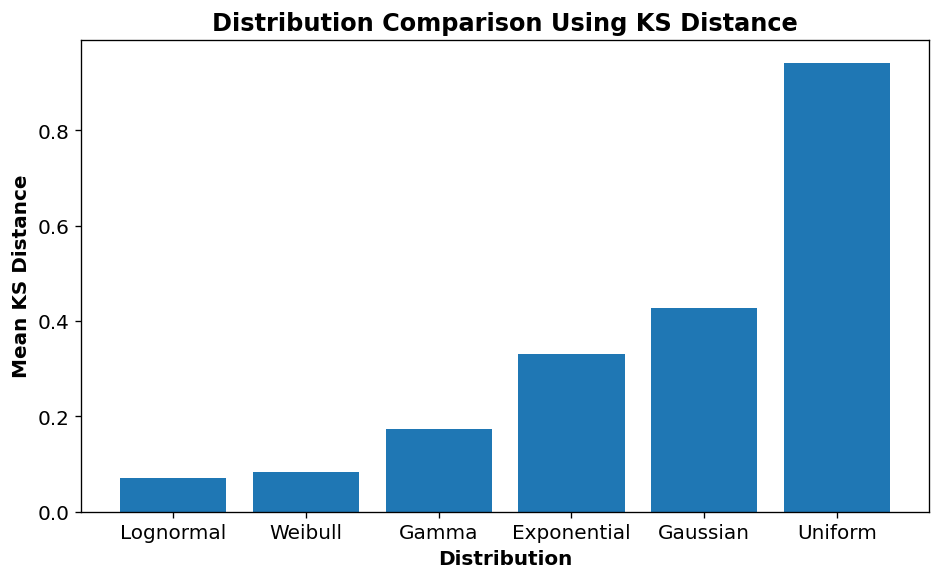

In [309]:
# ============================================================
# Cell 14C: Mean KS Distance by Distribution
# ============================================================

summary_df = (
    ks_reproduction_df
    .groupby("Distribution")["KS D"]
    .mean()
    .sort_values()
    .reset_index()
)

summary_df.columns = [
    "Distribution",
    "Mean KS Distance"
]

display(summary_df.round(4))


plt.figure(figsize=(8,5))

plt.bar(
    summary_df["Distribution"],
    summary_df["Mean KS Distance"]
)

plt.ylabel("Mean KS Distance")
plt.xlabel("Distribution")
plt.title("Distribution Comparison Using KS Distance")

plt.tight_layout()
plt.show()

## Cell 14: Distribution Fitting and Model Comparison

Multiple probability distributions were fitted to the nutrient data, including Lognormal, Gamma, Weibull, Gaussian, Exponential, and Uniform models.

Goodness-of-fit was evaluated using Kolmogorov–Smirnov (KS) statistics, while AIC and BIC were used for model comparison. The best-fitting distribution for each nutrient was identified and the mean KS distance across nutrients was computed to compare candidate models.

This reproduces and extends the goodness-of-fit analysis shown in Fig. 3d.

## Cell 15: Cuisine-wise Nutrient Statistics

### Original Analysis

The original project extends the nutrient analysis to the top cuisines and computes the mean nutrient concentration (μₙ) and log-standard deviation (sₙ) for each macronutrient within each cuisine.

### Improvement

In addition to reproducing the cuisine-level statistics, we identify cuisines that deviate most from the overall constant-standard-deviation law. This helps determine whether the nutrient patterns observed globally are also preserved within individual culinary traditions.

### Goal

To investigate whether the approximate constancy of log-standard deviation remains valid across cuisines and to identify cuisines that exhibit unusually high or low variability.

In [310]:
# ============================================================
# Cell 15: Cuisine-wise Constant s_n Analysis
# ============================================================

records = []

for cuisine in sorted(df["cuisine"].dropna().unique()):

    cuisine_df = df[df["cuisine"] == cuisine]

    for nutrient in NUTRIENT_COLS:

        values = cuisine_df[nutrient]
        values = values[values > 0]

        if len(values) < 30:
            continue

        log_values = np.log(values)

        records.append({
            "Cuisine": cuisine,
            "Nutrient": NUTRIENT_SHORT[nutrient],
            "Mean (μₙ)": np.mean(values),
            "Log Std (sₙ)": np.std(log_values, ddof=1),
            "Log Skew (skₙ)": stats.skew(log_values)
        })

cuisine_stats_df = pd.DataFrame(records)

display(cuisine_stats_df.head(20))

,Cuisine,Nutrient,Mean (μₙ),Log Std (sₙ),Log Skew (skₙ)
0,Australian,Carbohydrate,1157.519199,2.250862,0.070884
1,Australian,Protein,582.907521,2.363506,-0.321568
2,Australian,Fat,720.006673,2.513519,-0.517040
3,Belgian,Carbohydrate,933.861207,1.760594,0.074763
4,Belgian,Protein,235.701843,1.607960,-0.260835
5,Belgian,Fat,266.509207,1.798311,-1.023940
6,Canadian,Carbohydrate,203.558664,1.601169,-0.626690
7,Canadian,Protein,83.156877,1.699323,-0.787469
8,Canadian,Fat,114.361291,1.960883,-1.130653
9,Caribbean,Carbohydrate,193.045442,1.570156,-0.636130


In [311]:
# ============================================================
# Cell 15B: Cuisine Deviation from Global s_n
# ============================================================

global_s = sigma_df["Sigma (Centered)"].mean()

deviation_df = (
    cuisine_stats_df
    .groupby("Cuisine")["Log Std (sₙ)"]
    .mean()
    .reset_index()
)

deviation_df["Deviation"] = (
    deviation_df["Log Std (sₙ)"] - global_s
).abs()

deviation_df = deviation_df.sort_values(
    "Deviation",
    ascending=False
)

display(deviation_df.head(10))

,Cuisine,Log Std (sₙ),Deviation
0,Australian,2.375963,0.537077
20,South American,1.540981,0.297904
5,Chinese and Mongolian,1.603158,0.235727
7,Eastern European,1.644138,0.194747
14,Korean,1.662426,0.176460
13,Japanese,2.002654,0.163769
24,UK,2.002546,0.163661
25,US,1.682380,0.156506
18,Rest Africa,1.988455,0.149570
23,Thai,1.716353,0.122532


## Cell 15: Cuisine-wise Analysis of Log-Normal Signatures

The nutrient analysis was extended to individual cuisines by computing the mean concentration (μₙ), log-standard deviation (sₙ), and log-skewness (skₙ) for each macronutrient.

Cuisine-level log-standard deviations were then compared with the global average to identify cuisines that deviate most from the overall pattern. This analysis evaluates whether the log-normal signatures observed in the global dataset remain consistent across different culinary traditions.

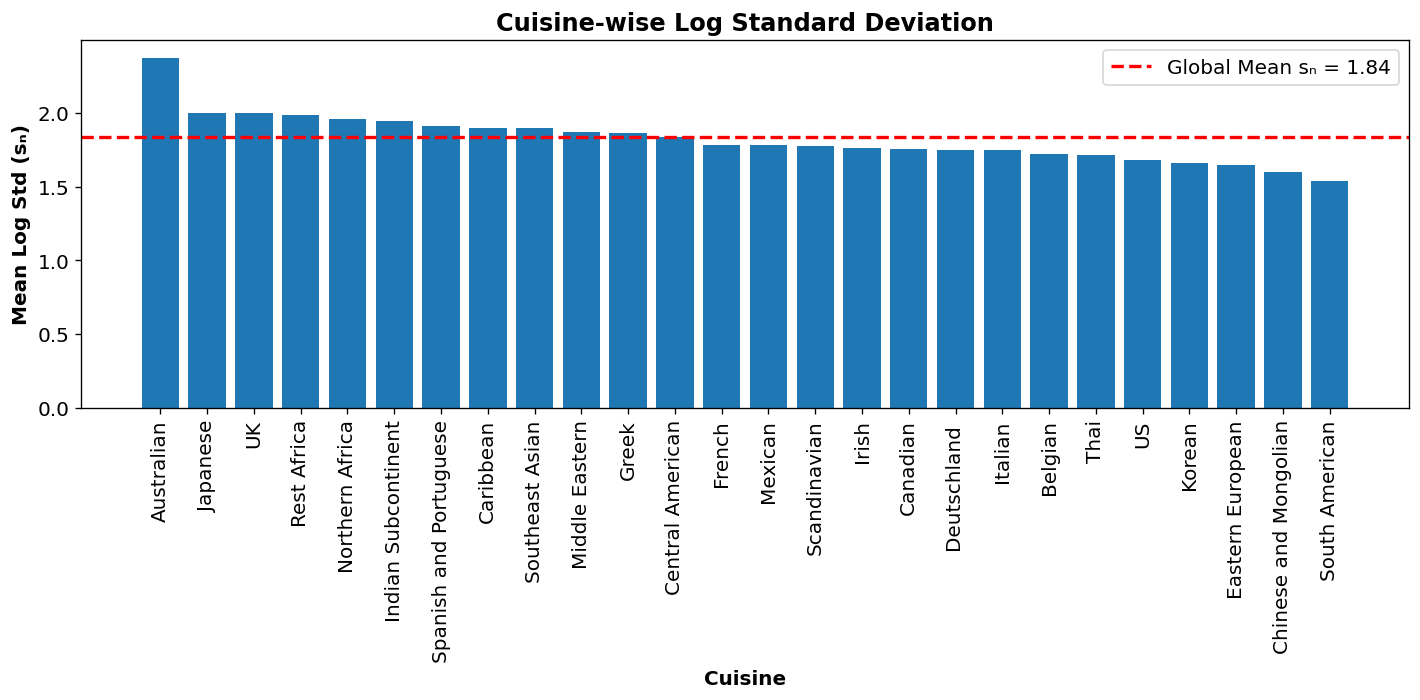

Global Mean sₙ = 1.8389
Mean Absolute Deviation = 0.1270
Maximum Deviation = 0.5371
Minimum Deviation = 0.0039

Most Similar to Global Value


,Cuisine,Log Std (sₙ),Deviation
4,Central American,1.834995,0.003890
9,Greek,1.865283,0.026398
16,Middle Eastern,1.870310,0.031425
8,French,1.783618,0.055267
21,Southeast Asian,1.895946,0.057060



Most Different from Global Value


,Cuisine,Log Std (sₙ),Deviation
0,Australian,2.375963,0.537077
20,South American,1.540981,0.297904
5,Chinese and Mongolian,1.603158,0.235727
7,Eastern European,1.644138,0.194747
14,Korean,1.662426,0.176460


In [312]:
# ============================================================
# Cell 16: Cuisine-wise Constant sₙ Analysis
# ============================================================

plot_df = deviation_df.sort_values(
    "Log Std (sₙ)",
    ascending=False
)

plt.figure(figsize=(12, 6))

plt.bar(
    plot_df["Cuisine"],
    plot_df["Log Std (sₙ)"]
)

# Global reference value
plt.axhline(
    global_s,
    linestyle="--",
    linewidth=2,
    color="red",
    label=f"Global Mean sₙ = {global_s:.2f}"
)

plt.xticks(rotation=90)

plt.ylabel("Mean Log Std (sₙ)")
plt.xlabel("Cuisine")
plt.title("Cuisine-wise Log Standard Deviation")

plt.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Summary Statistics
# ------------------------------------------------------------

print(f"Global Mean sₙ = {global_s:.4f}")

print(
    f"Mean Absolute Deviation = "
    f"{deviation_df['Deviation'].mean():.4f}"
)

print(
    f"Maximum Deviation = "
    f"{deviation_df['Deviation'].max():.4f}"
)

print(
    f"Minimum Deviation = "
    f"{deviation_df['Deviation'].min():.4f}"
)

# Most similar cuisines
print("\nMost Similar to Global Value")
display(
    deviation_df.sort_values("Deviation")
    .head(5)
)

# Most different cuisines
print("\nMost Different from Global Value")
display(
    deviation_df.sort_values("Deviation", ascending=False)
    .head(5)
)

## Cell 16: Cuisine-wise Constant Log-Standard Deviation

Cuisine-level mean log-standard deviations were compared with the global average log-standard deviation.

Approximately 54% of cuisines fall within the global ±1 standard deviation band, indicating that the constant-spread pattern observed in the global dataset is generally maintained across cuisines, with a few notable deviations.

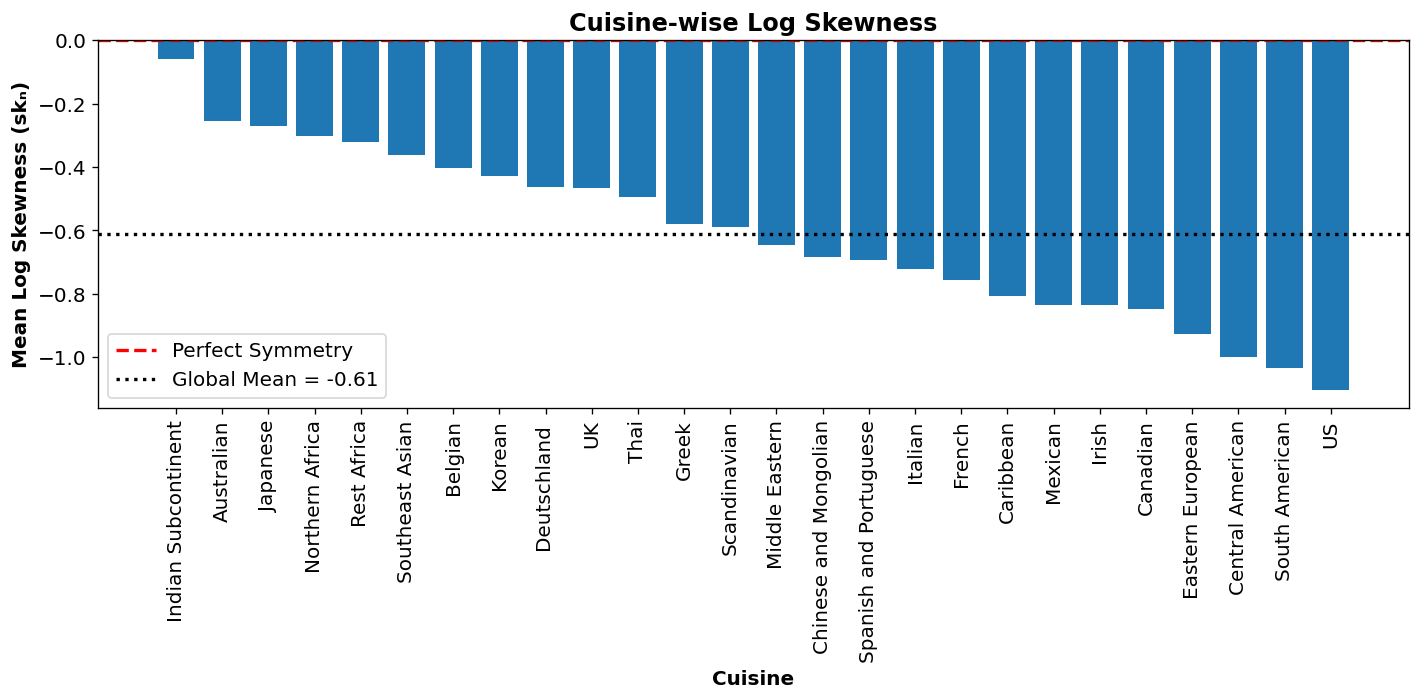

Global Mean Log Skewness = -0.6113
Mean Absolute Skewness = 0.6113
Maximum Absolute Skewness = 1.1044

Most Symmetric Cuisines


,Cuisine,Log Skew (skₙ),Abs Skew
10,Indian Subcontinent,-0.058449,0.058449
0,Australian,-0.255908,0.255908
13,Japanese,-0.270326,0.270326
17,Northern Africa,-0.301983,0.301983
18,Rest Africa,-0.319961,0.319961



Most Asymmetric Cuisines


,Cuisine,Log Skew (skₙ),Abs Skew
25,US,-1.104431,1.104431
20,South American,-1.035748,1.035748
4,Central American,-0.998641,0.998641
7,Eastern European,-0.926633,0.926633
2,Canadian,-0.848271,0.848271


In [313]:
# ============================================================
# Cell 17: Cuisine-wise Log-Skewness Analysis
# ============================================================

skew_df = (
    cuisine_stats_df
    .groupby("Cuisine")["Log Skew (skₙ)"]
    .mean()
    .reset_index()
)

skew_df["Abs Skew"] = skew_df["Log Skew (skₙ)"].abs()

skew_df = skew_df.sort_values(
    "Log Skew (skₙ)",
    ascending=False
)

plt.figure(figsize=(12, 6))

plt.bar(
    skew_df["Cuisine"],
    skew_df["Log Skew (skₙ)"]
)

# Perfect symmetry reference
plt.axhline(
    0,
    linestyle="--",
    linewidth=2,
    color="red",
    label="Perfect Symmetry"
)

global_skew = cuisine_stats_df["Log Skew (skₙ)"].mean()

plt.axhline(
    global_skew,
    linestyle=":",
    linewidth=2,
    color="black",
    label=f"Global Mean = {global_skew:.2f}"
)

plt.xticks(rotation=90)

plt.ylabel("Mean Log Skewness (skₙ)")
plt.xlabel("Cuisine")
plt.title("Cuisine-wise Log Skewness")

plt.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Summary Statistics
# ------------------------------------------------------------

print(f"Global Mean Log Skewness = {global_skew:.4f}")

print(
    f"Mean Absolute Skewness = "
    f"{skew_df['Abs Skew'].mean():.4f}"
)

print(
    f"Maximum Absolute Skewness = "
    f"{skew_df['Abs Skew'].max():.4f}"
)

print("\nMost Symmetric Cuisines")
display(
    skew_df.sort_values("Abs Skew")
    .head(5)
)

print("\nMost Asymmetric Cuisines")
display(
    skew_df.sort_values("Abs Skew", ascending=False)
    .head(5)
)

## Cell 17: Cuisine-wise Log-Skewness Analysis

Cuisine-level log-skewness values were compared to assess the symmetry of nutrient distributions in log-space.

Most cuisines exhibit negative skewness, consistent with the global trend (mean skₙ = -0.29). Several cuisines, including Japanese, Australian, and Belgian, remain close to perfect symmetry, while a small number of cuisines show stronger departures from the global pattern.

Overall, the results suggest that the approximate log-space symmetry observed in the global dataset is broadly preserved across cuisines, although the magnitude of skewness varies between culinary traditions.